# **Comparison of Artificial and Convolutional Neural Network**

In [5]:
# Import Libraries

import os
import pickle
import tarfile
import time

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Dense, Flatten, Conv2D, MaxPooling2D, Dropout, LeakyReLU)
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (confusion_matrix, classification_report, ConfusionMatrixDisplay )

The CIFAR 10 dataset contains 60,000 coloured images (32 x 32) pixels of objects across 10 categories, suitable for image recognition problems.

The dataset is divided into 50,000 training images and 10,000 testing images.

The line `datasets.cifar10.load_data()` is taking hours to execute on google colab so using the tar file from https://huggingface.co/Peyiloo/peyiloo/blob/main/cifar-10-python.tar.gz


Code: `!wget https://huggingface.co/Peyiloo/peyiloo/resolve/main/cifar-10-python.tar.gz`

In [6]:
# Uncomment before if not there
#!wget https://huggingface.co/Peyiloo/peyiloo/resolve/main/cifar-10-python.tar.gz

Note: For improving performance running in Google Colab's T4 Run Time to use GPU instead of standard CPU.

Insights numbers, values can change on new runs.

In [7]:
# Open tar file

path = "cifar-10-python.tar.gz"

with tarfile.open(path, "r:gz") as tar:
  tar.extractall()

/tmp/ipykernel_1747/1275788871.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [8]:
def load_batch(filename):
    with open(filename, 'rb') as f:
        data = pickle.load(f, encoding = 'bytes')

    X = data[b'data']
    y = data[b'labels']

    X = X.reshape(-1, 3, 32, 32)
    X = X.transpose(0, 2, 3, 1)

    y = np.array(y).reshape(-1, 1)

    return X, y

path = "cifar-10-batches-py"

X_train = []
y_train = []

for i in range(1, 6):
    X, y = load_batch(os.path.join(path, f"data_batch_{i}"))
    X_train.append(X)
    y_train.append(y)

X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)

X_test, y_test = load_batch(os.path.join(path, "test_batch"))

In [9]:
print("Training Images :", X_train.shape)
print("Labels :", y_train.shape)

print()

print("Testing Images :", X_test.shape)
print("Labels :", y_test.shape)

Training Images : (50000, 32, 32, 3)
Labels : (50000, 1)

Testing Images : (10000, 32, 32, 3)
Labels : (10000, 1)


In [10]:
# Classes
classes = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck" ]

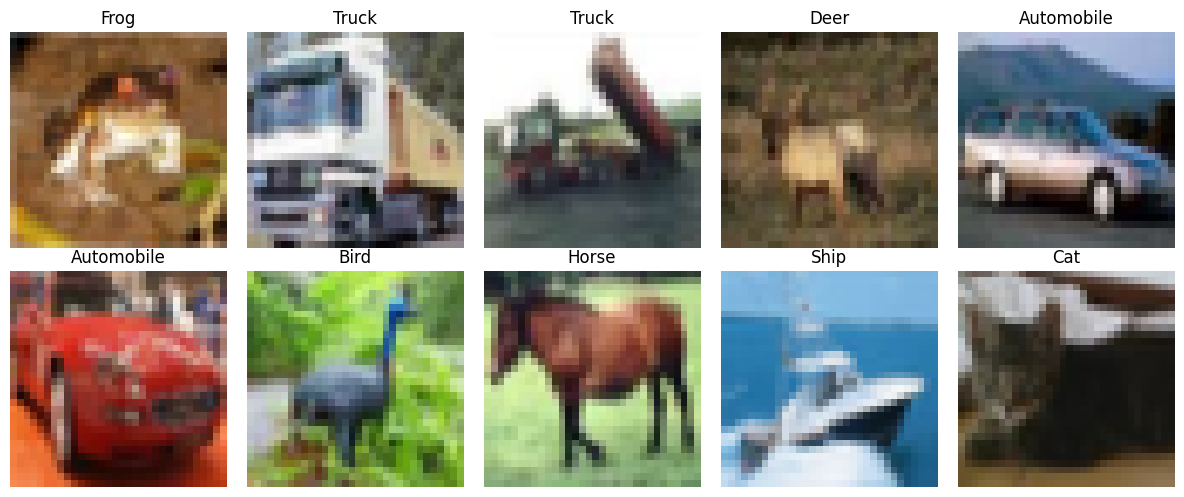

In [11]:
# Plot of training images
plt.figure(figsize = (12, 5))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(classes[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# Normalise X to [0, 1]

X_train = X_train / 255
X_test = X_test / 255

Pixel values are from 0 to 255 by normalising them in range [0, 1]

Normalization helps to improve training stability, speeds model convergence and enables efficient gradient descent due to common scale and no large values.

# Artificial Neural Network

In [13]:
# ANN Model
ann_model = Sequential()

# Input layer
ann_model.add(Input(shape = (32, 32, 3)))
ann_model.add(Flatten())

# Hidden layer
ann_model.add(Dense(512))
ann_model.add(LeakyReLU(negative_slope = 0.01))

ann_model.add(Dense(256))
ann_model.add(LeakyReLU(negative_slope = 0.01))

ann_model.add(Dense(128))
ann_model.add(LeakyReLU(negative_slope = 0.01))

# Output layer
ann_model.add(Dense(10, activation = "softmax"))

The Flatten layer converts the 32 x 32 pixel size to a 1d array of size 1024 * 3 = 3072 so the input can be processed easily.

The hidden layers with 512, 256, 128 neurons uses Leaky ReLU activation function to learn complex patterns.

Leaky ReLU used as it improves the range and prevents dead neurons allowing non zero gradient (negative values).

The output uses a softmax function with 10 neurons to produce probability distribution over the 10 classes.

In [14]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

```
Parameters:

1) flatten_4  32 * 32 * 3 = 3072
2) dense_16   (3072 + 1)* 512 = 1,573,376
3) dense_17   (512 + 1) * 256 = 131,328
4) dense_18   (256 + 1)* 128 = 32896
5) dense_19   (128 + 1) * 10 = 1290


In [15]:
# Compile Model

# Categorical loss to avoid encoding
ann_model.compile(loss = "sparse_categorical_crossentropy", optimizer = 'adam', metrics = ['accuracy'])

In [16]:
# Train Model for 10 epochs

start_time = time.time()

ann_history = ann_model.fit(X_train, y_train, batch_size = 64, epochs = 10, validation_split = 0.2)

ann_training_time = time.time() - start_time

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3097 - loss: 1.9058 - val_accuracy: 0.3210 - val_loss: 1.8597
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3807 - loss: 1.7103 - val_accuracy: 0.3723 - val_loss: 1.7548
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4169 - loss: 1.6310 - val_accuracy: 0.4156 - val_loss: 1.6444
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4372 - loss: 1.5659 - val_accuracy: 0.4325 - val_loss: 1.5825
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4588 - loss: 1.5145 - val_accuracy: 0.4448 - val_loss: 1.5612
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4656 - loss: 1.4904 - val_accuracy: 0.4486 - val_loss: 1.5470
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4775 - loss: 1.4529 - val_accuracy: 0.4656 - val_loss: 1.5228
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4914 - loss: 1.4224 - val_accuracy: 0.

10 epochs used to compare accuracy with CNN model and 20 % data is used for validation.

In [17]:
# Loss, Accuracy and Time to Train

ann_loss, ann_accuracy = ann_model.evaluate(X_test, y_test, verbose = 0)

print(f"Test Loss     : {ann_loss:.4f}")
print(f"Test Accuracy : {ann_accuracy * 100:.2f} %")

print(f"\nTraining Time : {ann_training_time:.2f} seconds")

Test Loss     : 1.4534
Test Accuracy : 48.57 %

Training Time : 30.63 seconds


Accuracy around 48 % indicates poor-average performance. For ANN more epochs are needed. Due to 10 epochs the model is slightly underfitted.

The loss of 1.5 is also quite high.

The training time is low due to GPU if CPU used then around few mins.

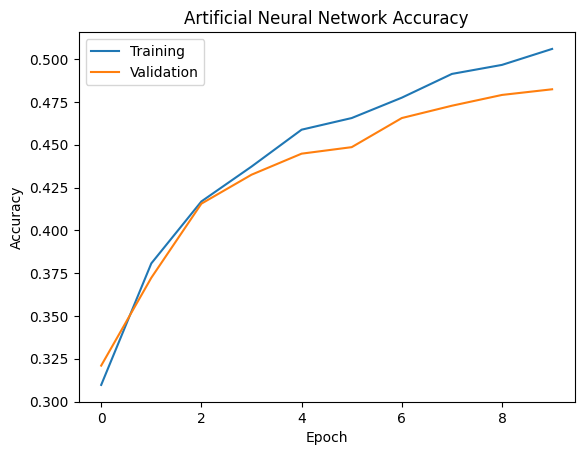

In [18]:
# Training and Validation Accuracy

plt.plot(ann_history.history['accuracy'], label = "Training")
plt.plot(ann_history.history['val_accuracy'], label = "Validation")

plt.title("Artificial Neural Network Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

The Training and Validation Accuracy are consistent.

The accuracy increases showing that the model is learning effectively and picking patterns.

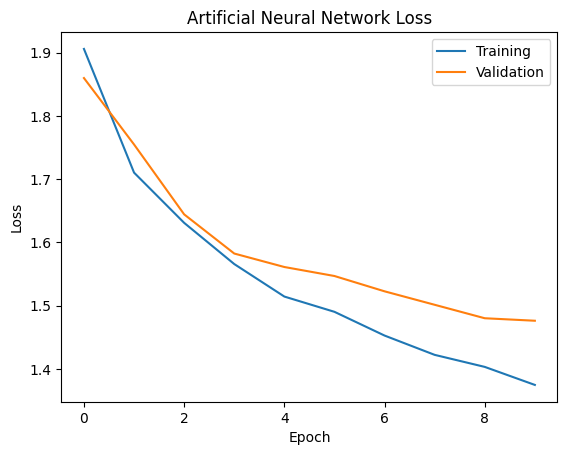

In [19]:
# Training and validation loss

plt.plot(ann_history.history['loss'], label = "Training")
plt.plot(ann_history.history['val_loss'], label = "Validation")

plt.title("Artificial Neural Network Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

The loss is consistently decreasing showing effective learning with some signs of slight over fitting after 6th epoch.

In [20]:
# Predict
y_prob_ann = ann_model.predict(X_test)

# Predict the value using argmax
y_pred_ann = y_prob_ann.argmax(axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


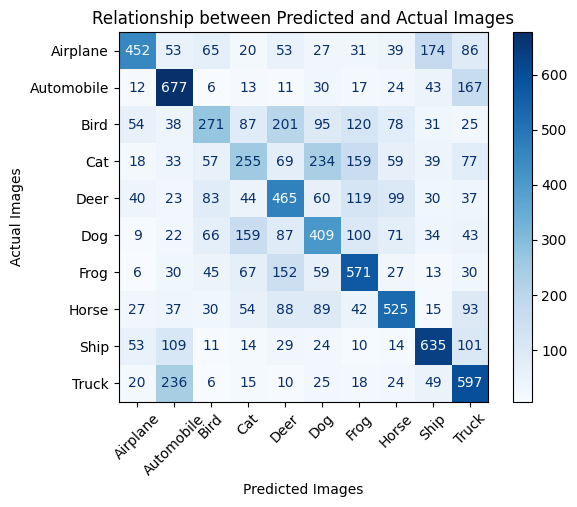

In [21]:
# Relation between Predicted and Actual Images
disp = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_test, y_pred_ann), display_labels = classes)

disp.plot(cmap = 'Blues', xticks_rotation = 45)

plt.xlabel("Predicted Images")
plt.ylabel("Actual Images")
plt.title("Relationship between Predicted and Actual Images")
plt.show()

From the confusion matrix plot, we can see that Automobile, Ship have been identified most accurately primarily due to their unique shape and structure.

Some of the features have not been identified clearly and have lot of overlaps.

Bird, Cat, Dog due to the similarity in design and colours have been identified the least.

Few errors have occured for (Cat, Dog), (Truck, Automobile), (Bird, Deer) due their similarities in design, colours.

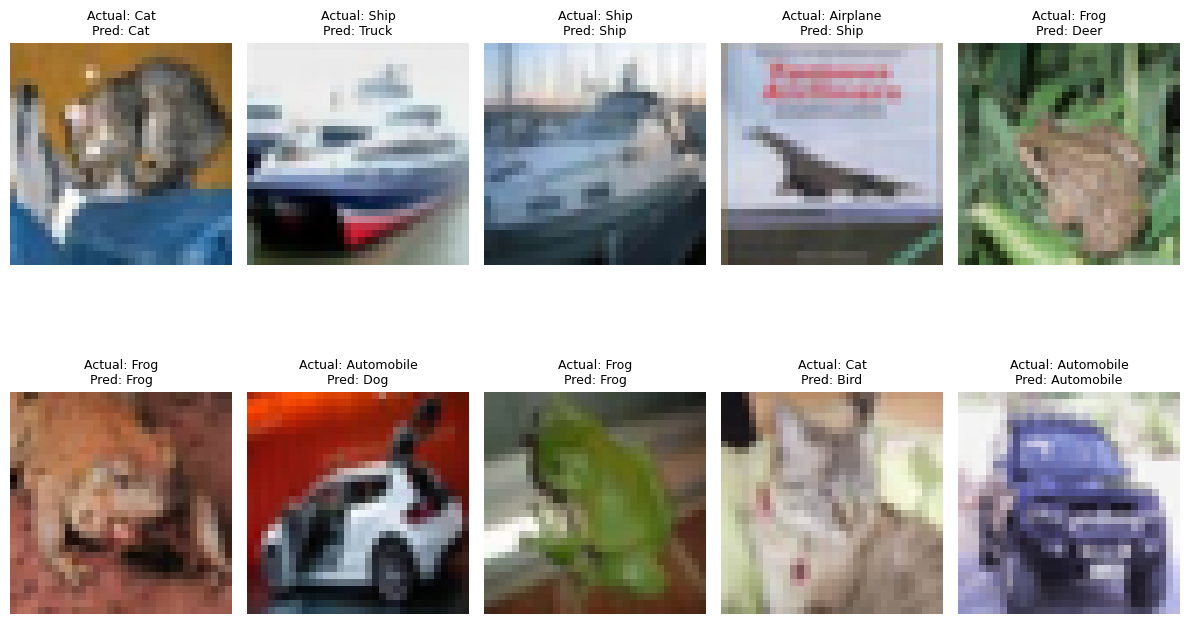

In [22]:
# Plot of Predictions

plt.figure(figsize = (12, 8))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i])

    actual = classes[y_test[i][0]]
    predicted = classes[y_pred_ann[i]]

    plt.title(f"Actual: {actual}\nPred: {predicted}", fontsize = 9)
    plt.axis("off")

plt.tight_layout()

plt.show()

Mostly animals have been categorised but Automobile being Dog can be due to the orientation and colour being similar.

In [23]:
# Classification report

print(classification_report(y_test, y_pred_ann, target_names = classes))

              precision    recall  f1-score   support

    Airplane       0.65      0.45      0.53      1000
  Automobile       0.54      0.68      0.60      1000
        Bird       0.42      0.27      0.33      1000
         Cat       0.35      0.26      0.30      1000
        Deer       0.40      0.47      0.43      1000
         Dog       0.39      0.41      0.40      1000
        Frog       0.48      0.57      0.52      1000
       Horse       0.55      0.53      0.54      1000
        Ship       0.60      0.64      0.62      1000
       Truck       0.48      0.60      0.53      1000

    accuracy                           0.49     10000
   macro avg       0.49      0.49      0.48     10000
weighted avg       0.49      0.49      0.48     10000



As a summary for ANN, the model is struggling to learn the features of the images.

The best performing class is Automobile (68 % recall) due to the vehicles shape distinct from others.

The worst performing class is Bird, Cat (27 % recall) due to similarities in design and colour with other animals.

Vehicles and Animals can be identified apart but sub groups are hard to distinguish like in example of cat and bird, automobile, ship due to similar features.

ANN receives a vector resulting in loss of edge information, local patterns and objects in different locations.

With accuracy of 45 - 48 % it performs better than random guessing (10 %) but still performs poorly.

# Convolutional Neural Network

In [38]:
cnn_model = Sequential()

# Input layer
cnn_model.add(Input(shape = (32, 32, 3)))

# Convolution
cnn_model.add(Conv2D(32, (3, 3), padding = 'same'))  # Same Padding for corners
cnn_model.add(LeakyReLU(negative_slope = 0.01))
cnn_model.add(MaxPooling2D((2, 2)))   # Pool

cnn_model.add(Conv2D(64, (3, 3), padding = 'same'))
cnn_model.add(LeakyReLU(negative_slope = 0.01))
cnn_model.add(MaxPooling2D((2, 2)))

cnn_model.add(Conv2D(128, (3, 3), padding = 'same'))
cnn_model.add(LeakyReLU(negative_slope = 0.01))
cnn_model.add(MaxPooling2D((2, 2)))

# Flatten
cnn_model.add(Flatten())

# Fully Connected Layers
cnn_model.add(Dense(128))
cnn_model.add(LeakyReLU(negative_slope = 0.01))
cnn_model.add(Dropout(0.5))

# Output Layer
cnn_model.add(Dense(10, activation = 'softmax'))

Input layer 32 x 32 x 3 undergoes convolution thrice with leaky ReLU to prevent dying neurons and same padding to add importance to corners.

Max Pooling is used to reduce feature map size.

Then the model is flattened to map the features and passed through fully connected layers.

The output uses a softmax function with 10 neurons to produce probability distribution over the 10 image classes.

In [39]:
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

```
Parameters:

Filters size (3, 3)

1) conv2d (3*3*3 + 1) * 32 = 896
2) conv2d_1 (3*3*32 + 1) * 64 = 18,496
3) conv2d_2 (3*3*64 + 1) * 128 = 73,856
(Fh * Fw * Input + 1) * Filters

4) dense_24 (2048 + 1) * 128 = 262,272
5) dense_25 (128 + 1) * 10 = 1290
(Input + 1) * Outputs

In [40]:
# Compile Model

# Categorical loss to avoid encoding
cnn_model.compile(loss = "sparse_categorical_crossentropy", optimizer = 'adam', metrics = ['accuracy'])

In [41]:
# Train Model for 10 epochs

start_time = time.time()

cnn_history = cnn_model.fit(X_train, y_train, batch_size = 64, epochs = 10, validation_split = 0.2)

cnn_training_time = time.time() - start_time

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3919 - loss: 1.6663 - val_accuracy: 0.5366 - val_loss: 1.2822
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5606 - loss: 1.2350 - val_accuracy: 0.6137 - val_loss: 1.0915
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6358 - loss: 1.0313 - val_accuracy: 0.6720 - val_loss: 0.9223
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6836 - loss: 0.9028 - val_accuracy: 0.6974 - val_loss: 0.8675
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7193 - loss: 0.8039 - val_accuracy: 0.7316 - val_loss: 0.7807
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7456 - loss: 0.7263 - val_accuracy: 0.7362 - val_loss: 0.7690
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7691 - loss: 0.6534 - val_accuracy: 0.7357 - val_loss: 0.7736
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7894 - loss: 0.5989 - val_accuracy: 0.

In [28]:
# Loss, Accuracy and Time to Train

cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test, y_test, verbose = 0)

print(f"Test Loss     : {cnn_loss:.4f}")
print(f"Test Accuracy : {cnn_accuracy * 100:.2f} %")

print(f"\nTraining Time : {cnn_training_time:.2f} seconds")

Test Loss     : 0.7694
Test Accuracy : 75.52 %

Training Time : 44.01 seconds


Comparing with the performance of ANN Model:

1) The CNN's loss is half of the ANN's showcasing better learning for the model.

2) The Accuracy has increased to about 75 % better than earlier 47 % showing good performance for 10 epochs.

3) The training time is higher than ANN, CPU takes longer time due to it doing calculations sequentially, improved with GPU

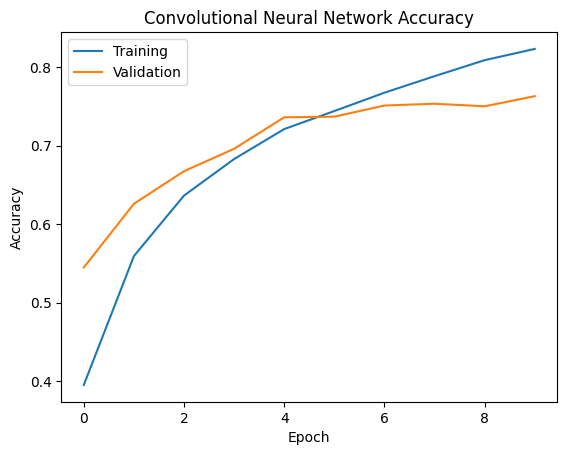

In [29]:
# Plot Training and Validation Accuracy

plt.plot(cnn_history.history['accuracy'], label = "Training")
plt.plot(cnn_history.history['val_accuracy'], label = "Validation")

plt.title("Convolutional Neural Network Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Like the ANN Graph training and validation are consistent till 6th epoch then there is slight over fitting of data.

The accuracy increases upto 0.8 showing great learning of patterns.

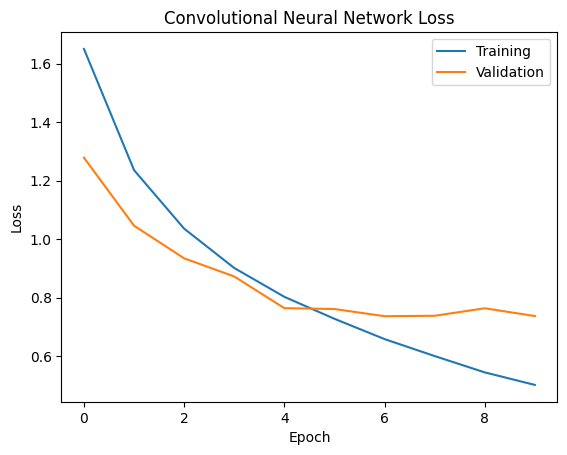

In [30]:
# Plot of Training and validation loss

plt.plot(cnn_history.history['loss'], label = "Training")
plt.plot(cnn_history.history['val_loss'], label = "Validation")

plt.title("Convolutional Neural Network Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

The training loss consistently decreases but the validation loss increases around 6th epoch showing the overfitting nature.

Loss is still lower than ANN's loss of around 1.5 despite the over fitting indicating great pattern recognition

Despite the overfitting in both the cases CNN performs better than ANN model.

In [31]:
# Predict
y_prob_cnn = cnn_model.predict(X_test)

# Predict the value using argmax
y_pred_cnn = y_prob_cnn.argmax(axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


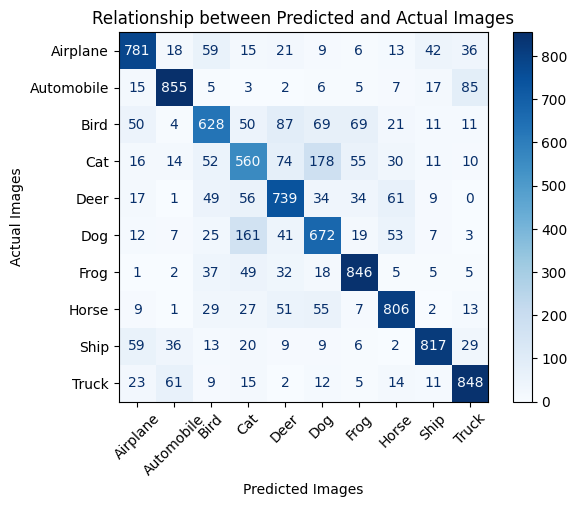

In [32]:
# Relation between Predicted and Actual Images
disp = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_test, y_pred_cnn), display_labels = classes)

disp.plot(cmap = 'Blues', xticks_rotation = 45)

plt.xlabel("Predicted Images")
plt.ylabel("Actual Images")
plt.title("Relationship between Predicted and Actual Images")
plt.show()

The improvement from the case of ANN is seen from the plot. We can find that Frogs, Ships, Automobiles, Trucks have been identified correctly the most with improved numbers from the ANN plot.

However the model still confuses between (Cat, Dog), (Automobile, Truck) due to these being very similar in design and features and require more epochs training to identify better.

Most of the categories have been correctly identified.

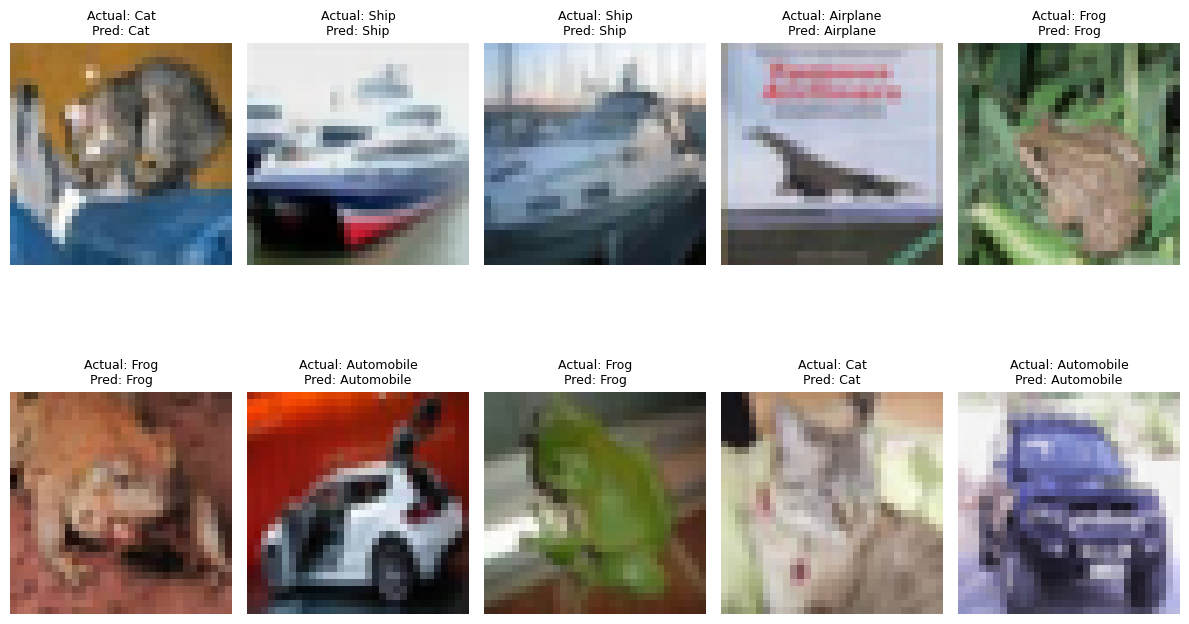

In [33]:
# Plot of Predictions

plt.figure(figsize = (12, 8))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i])

    actual = classes[y_test[i][0]]
    predicted = classes[y_pred_cnn[i]]

    plt.title(f"Actual: {actual}\nPred: {predicted}", fontsize = 9)
    plt.axis("off")

plt.tight_layout()

plt.show()

We can see all correct predictions for the first 10 sample showing improvement from the ANN model, showing that CNN is perfect for identifying unique features and categorising into classes.

Some irregularities can occur due to 75 % accuracy.

In [34]:
# Mismatches

print("Mismatches of ANN: ", np.sum(y_pred_ann != y_test.flatten()), "/", len(y_test.flatten()))
print("Mismatches of CNN: ", np.sum(y_pred_cnn != y_test.flatten()), "/", len(y_test.flatten()))

Mismatches of ANN:  5143 / 10000
Mismatches of CNN:  2448 / 10000


From the mismatches data, ANN has misidentified around half of the images.

CNN has misidentified 25% of the images showing great improvement over ANN demonstrating great performance in identifying patterns.

In [35]:
# Parameters

print("ANN Parameters :", ann_model.count_params())
print("CNN Parameters :", cnn_model.count_params())

ANN Parameters : 1738890
CNN Parameters : 356810


CNN has 1/6th parameters of ANN and still predicts accurately despite having fewer parameters.

This is due to CNN sharing weights and preserving spatial hierarchies.

In [36]:
# Training time taken
print("ANN Training Time :", round(ann_training_time, 3), "seconds")
print("CNN Training Time :", round(cnn_training_time, 3), "seconds")

ANN Training Time : 30.626 seconds
CNN Training Time : 44.007 seconds


CNN takes 1.5 the training time and can worsen without GPU due to performing matrix convolutions taking O(N^2) time.

In [37]:
# Classification report

print(classification_report(y_test, y_pred_cnn, target_names = classes))

              precision    recall  f1-score   support

    Airplane       0.79      0.78      0.79      1000
  Automobile       0.86      0.85      0.86      1000
        Bird       0.69      0.63      0.66      1000
         Cat       0.59      0.56      0.57      1000
        Deer       0.70      0.74      0.72      1000
         Dog       0.63      0.67      0.65      1000
        Frog       0.80      0.85      0.82      1000
       Horse       0.80      0.81      0.80      1000
        Ship       0.88      0.82      0.85      1000
       Truck       0.82      0.85      0.83      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.75     10000
weighted avg       0.76      0.76      0.75     10000



The values for precision, recall, f1-score have increased from the earlier 25 to 65 range to 50 to 85 range showing improved predictions and categorisation.

Considering recall Automobile, Truck have been identified clearly and not misconsidered for other categories.

Bird, Cat, Dog have the lowest parameters but have improved significantly from earliest 20s to 60s due to improved features in CNN like Pooling, Padding, Feature maps.

Thus CNN shows higher accuracy than ANN demonstrating its effectiveness in identifying images and classifying them into classes.

#**Overall Conclusion**

ANN showed moderate accuracy as it processed flattened 1 d arrays removing spatial relationships among pixels and limits ability to learn features.

While ANN received an initial 1d array, CNN preserves the 2d spatial structure by convolutional filters and padding to learn features like edges, texture and shape. Pooling reduces dimensions and makes it tolerate translations.

Thus CNN achieved significantly higher accuracy and more reliable predictions across most of the categories.

Although CNN took more training time its performance balances it and makes it preferable for image recognition.

